## Data Preprocessing and Exploration

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import time
import polars as pl  # very fast and low memory
import glob
from sklearn.neural_network import MLPRegressor


In [3]:
# Load the ecommerce behaviour dataset

df = pd.read_csv('../data/2019-Oct.csv')
print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [5]:
# Dataset Overview
print("Shape:", df.shape)
print("\n")

# Detailed Info
print("Dataset Info:")
print("="*50)
df.info()
print("\n")

# Statistical Summary
print("Statistical Description:")
print("="*50)
with pd.option_context('display.max_columns', None, 
                        'display.width', None,
                        'display.float_format', '{:.2f}'.format):
    print(df.describe(include='all'))

Shape: (42448764, 9)


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 42448764 entries, 0 to 42448763
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 2.8 GB


Statistical Description:
                     event_time event_type  product_id            category_id  \
count                  42448764   42448764 42448764.00            42448764.00   
unique                  2621538          3         NaN                    NaN   
top     2019-10-15 08:52:00 UTC       view         NaN                    NaN   
freq                        116   40779399         NaN                    NaN   
mean                        NaN        NaN 10549932.38 2057404

### Exploratory Data Analysis

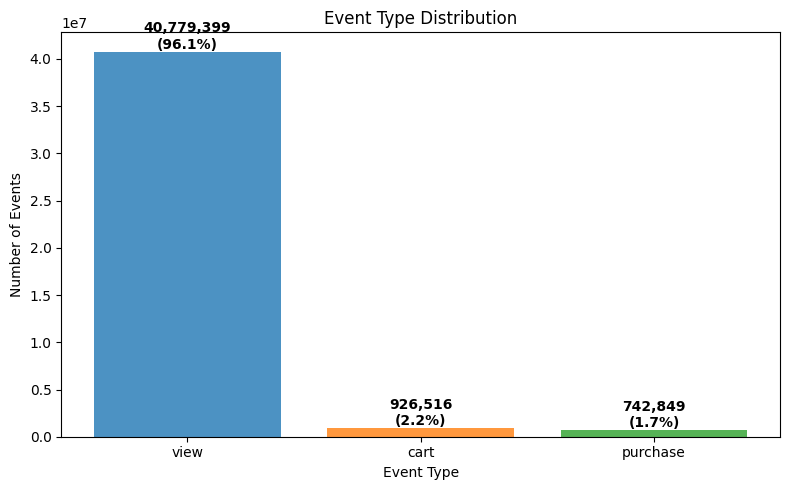

In [6]:
# Visualization of event type distribution
# Bar chart showing count and percentage of each event type (view, cart, purchase)

plt.figure(figsize=(8, 5))
event_counts = df['event_type'].value_counts()  # Count occurrences of each event type
bars = plt.bar(event_counts.index, event_counts.values, 
               color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.8)

# Add count and percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:,}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')

plt.title('Event Type Distribution')
plt.xlabel('Event Type')
plt.ylabel('Number of Events')
plt.tight_layout()
plt.show()

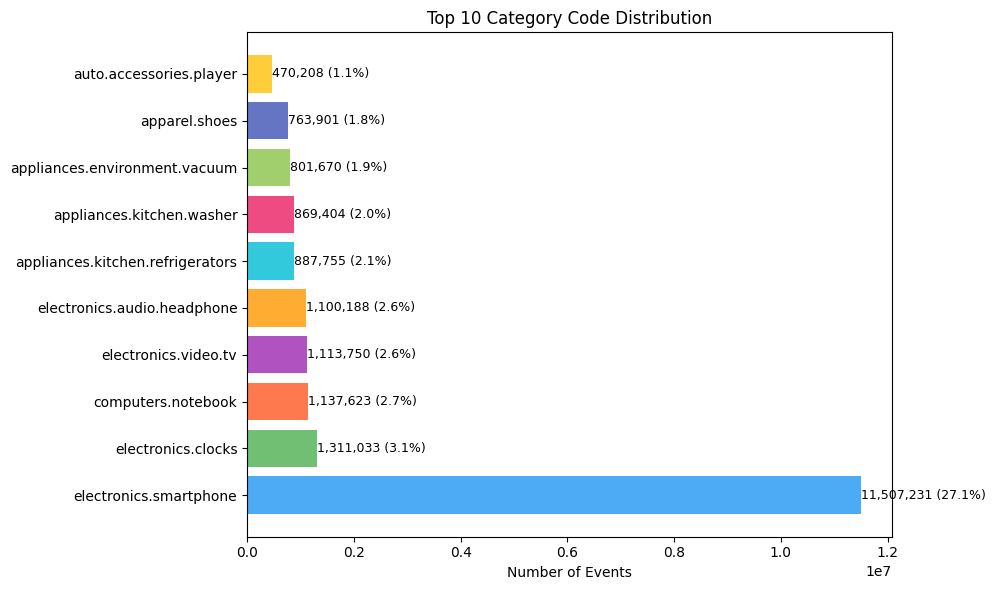

In [7]:
# Visualization of top 10 category_code values
# Horizontal bar chart — best for long category names, easy rank comparison

top_categories = df['category_code'].value_counts().nlargest(10)  # Get top 10 categories by frequency

# Define distinct colors for each bar
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800',
          '#00BCD4', '#E91E63', '#8BC34A', '#3F51B5', '#FFC107']

plt.figure(figsize=(10, 6))
bars = plt.barh(top_categories.index, top_categories.values, color=colors, alpha=0.8)

# Add count and percentage labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
             f'{width:,} ({width/len(df)*100:.1f}%)',
             ha='left', va='center', fontsize=9)

plt.title('Top 10 Category Code Distribution')
plt.xlabel('Number of Events')
plt.tight_layout()
plt.show()

C:\Users\shire\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


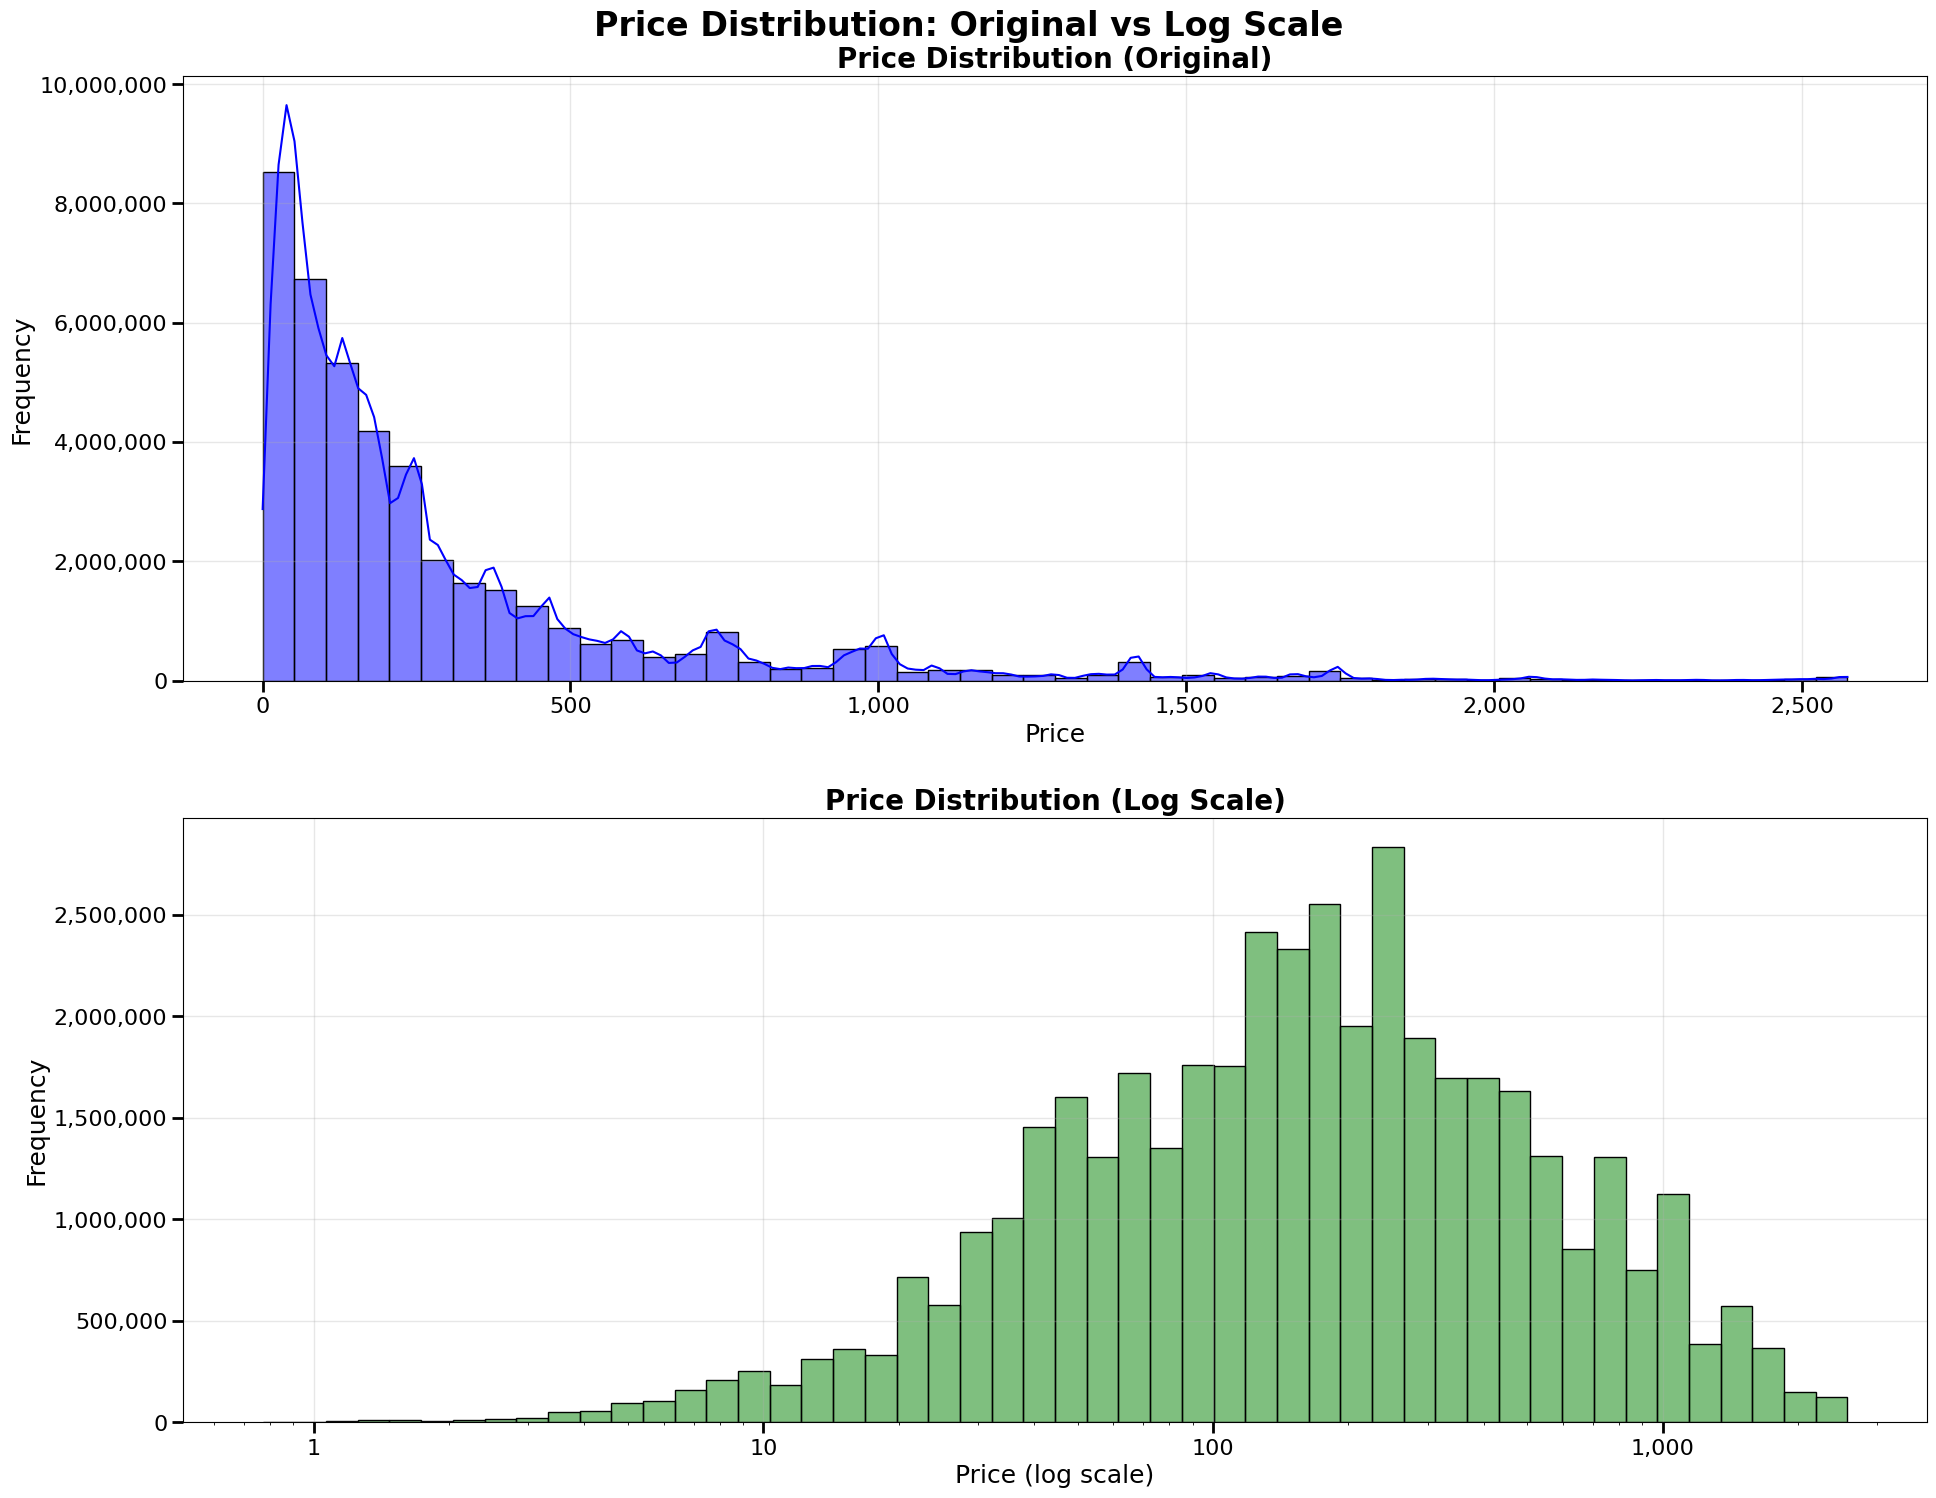

In [8]:
# Maximum visibility for axes values
fig, axes = plt.subplots(2, 1, figsize=(20, 16))

# Disable scientific notation for better readability
plt.rcParams['axes.formatter.useoffset'] = False

# Top plot
sns.histplot(df['price'], bins=50, kde=True, color='blue', ax=axes[0])
axes[0].set_title('Price Distribution (Original)', fontsize=20, fontweight='bold')
axes[0].set_xlabel('Price', fontsize=18)
axes[0].set_ylabel('Frequency', fontsize=18)
axes[0].tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format x-axis
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format y-axis
axes[0].grid(True, alpha=0.3, linewidth=1)

# Bottom plot
sns.histplot(df['price'], bins=50, kde=True, log_scale=True, color='green', ax=axes[1])
axes[1].set_title('Price Distribution (Log Scale)', fontsize=20, fontweight='bold')
axes[1].set_xlabel('Price (log scale)', fontsize=18)
axes[1].set_ylabel('Frequency', fontsize=18)
axes[1].tick_params(axis='both', which='major', labelsize=16, width=2, length=8)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format x-axis
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))  # Format y-axis
axes[1].grid(True, alpha=0.3, linewidth=1)

plt.suptitle('Price Distribution: Original vs Log Scale', fontsize=24, fontweight='bold', y=0.95)
plt.tight_layout(pad=3.0)
plt.show()

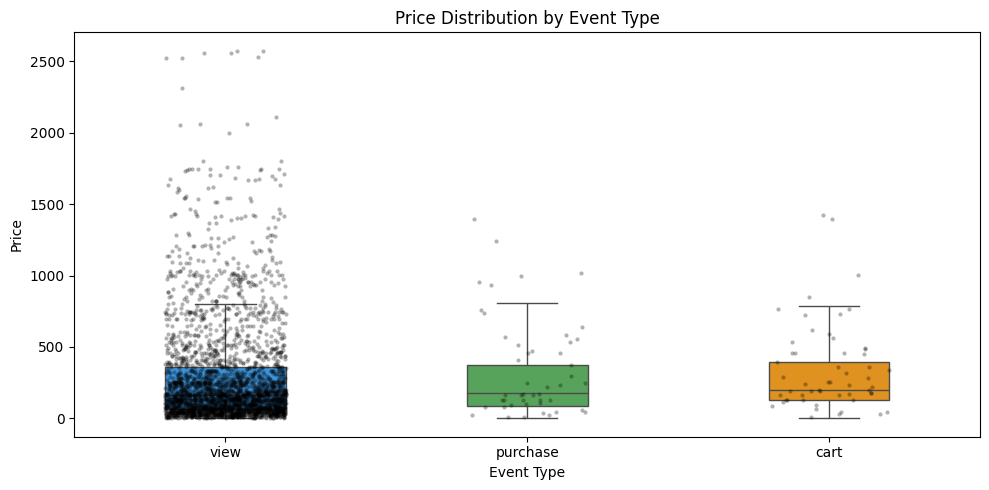

In [9]:
# Scatter Plot: Price vs Event Type
# Box plot overlaid with stripplot — combines summary statistics with individual data points
# Shows median, IQR, outliers AND raw distribution simultaneously

plt.figure(figsize=(10, 5))

# Base layer: box plot — hue set explicitly to suppress FutureWarning
sns.boxplot(x='event_type', y='price', data=df,
            hue='event_type',  # Explicitly assign hue to match x variable
            palette={'view': '#2196F3', 'cart': '#FF9800', 'purchase': '#4CAF50'},
            width=0.4, fliersize=0,  # fliersize=0 hides outlier dots from boxplot
            legend=False)  # Suppress legend since x-axis already labels event types

# Top layer: individual points sampled for readability
sns.stripplot(x='event_type', y='price', data=df.sample(3000),
              color='black', alpha=0.3, jitter=0.2, size=3)  # Black dots overlay for raw data points

plt.title('Price Distribution by Event Type')
plt.xlabel('Event Type')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

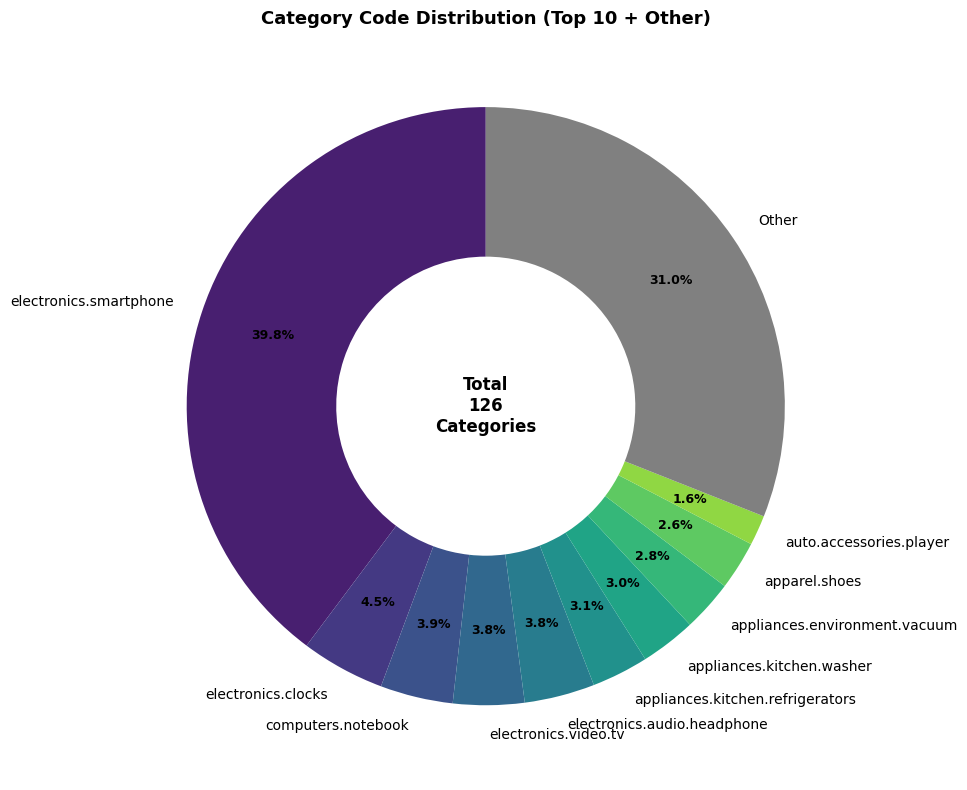

In [10]:
# Visualization of top 10 category_code values + Other
# Donut chart — cleaner than pie chart, centre space can display key insight

# Combine smaller categories into 'Other'
category_counts = df['category_code'].value_counts()
top_n = 10
top_categories = category_counts[:top_n].copy()  # Get top 10 categories
other_count = category_counts[top_n:].sum()       # Sum all remaining categories
top_categories['Other'] = other_count             # Add 'Other' as final slice

# Define distinct colors for each slice
colors = sns.color_palette('viridis', len(top_categories))
colors[-1] = (0.5, 0.5, 0.5)  # Set 'Other' slice to grey for visual distinction

plt.figure(figsize=(10, 8))

# Draw donut — wedgeprops width controls thickness (0=full circle, 1=no hole)
wedges, texts, autotexts = plt.pie(top_categories.values,
                                    labels=top_categories.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    wedgeprops=dict(width=0.5),  # Controls donut hole size
                                    pctdistance=0.75)            # Position percentage labels inside ring

# Style percentage labels for readability
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

# Add centre text showing total number of categories
plt.text(0, 0, f'Total\n{len(category_counts)}\nCategories',
         ha='center', va='center', fontsize=12, fontweight='bold')  # Centre label inside donut hole

plt.title('Category Code Distribution (Top 10 + Other)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

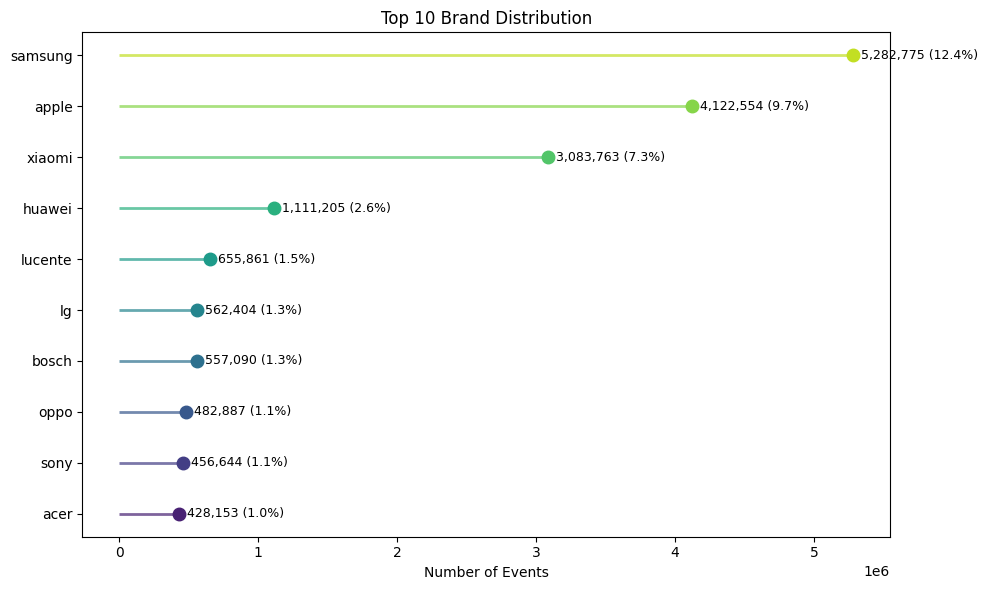

In [11]:
# Visualization of top 10 brands by interaction frequency
# Lollipop chart — modern clean alternative to bar chart, reduces visual clutter

# Get top 10 brands sorted ascending for readability
top_brands = df['brand'].value_counts().nlargest(10).sort_values()

colors = sns.color_palette('viridis', len(top_brands))

plt.figure(figsize=(10, 6))

# Draw horizontal lines from 0 to each brand's count
for i, (brand, val) in enumerate(zip(top_brands.index, top_brands.values)):
    plt.hlines(y=brand, xmin=0, xmax=val, color=colors[i], linewidth=2, alpha=0.7)

# Draw dot at the end of each line
for i, (brand, val) in enumerate(zip(top_brands.index, top_brands.values)):
    plt.plot(val, brand, 'o', color=colors[i], markersize=9)

# Add value labels next to each dot
for brand, val in zip(top_brands.index, top_brands.values):
    plt.text(val, brand, f'  {val:,} ({val/len(df)*100:.1f}%)',
             va='center', fontsize=9)

plt.title('Top 10 Brand Distribution')
plt.xlabel('Number of Events')
plt.tight_layout()
plt.show()

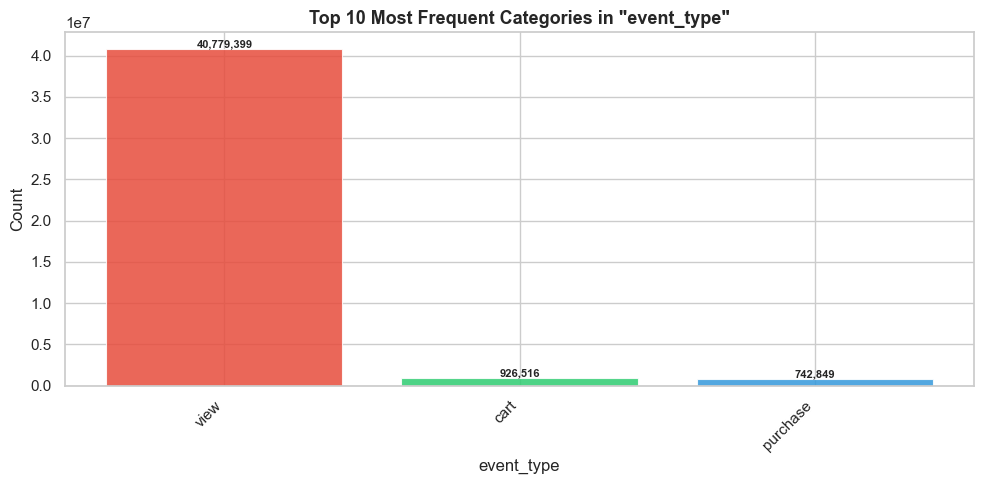

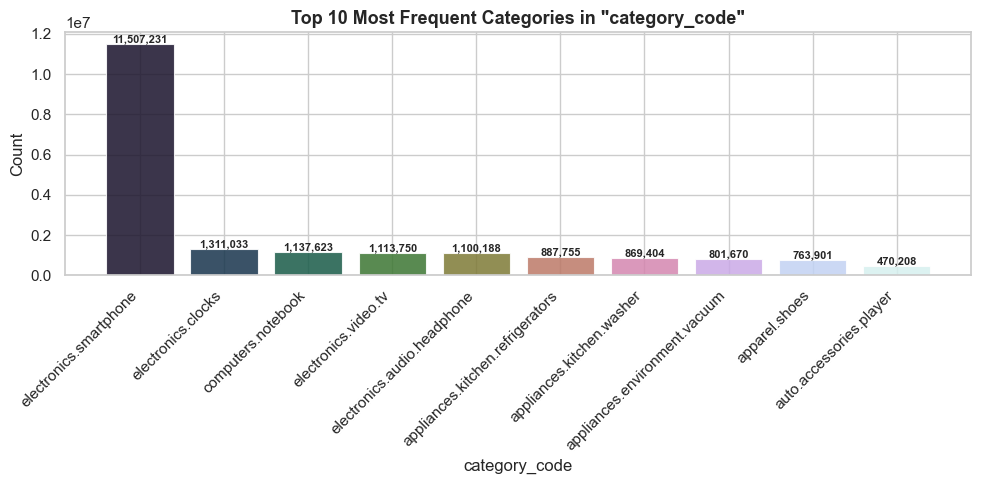

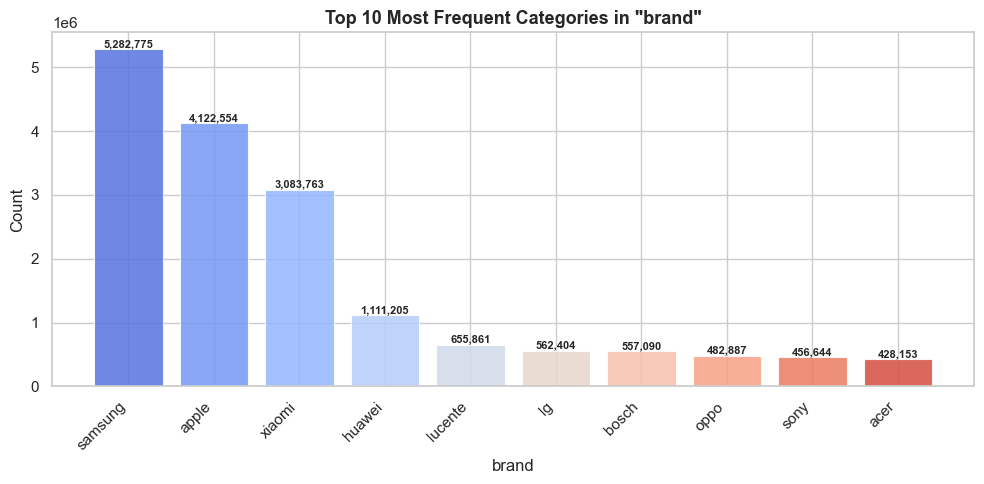

In [12]:
# Visualization of categorical columns
# Bar charts — shows top 10 most frequent values for each categorical column

sns.set(style="whitegrid")

categorical_cols = ['event_type', 'category_code', 'brand']

# Define a unique color palette for each column
column_colors = {
    'event_type'    : ['#E74C3C', '#2ECC71', '#3498DB'],                          # Red, Green, Blue — only 3 values
    'category_code' : sns.color_palette('cubehelix', 10).as_hex(),                # Cubehelix gradient for 10 categories
    'brand'         : sns.color_palette('coolwarm', 10).as_hex()                  # Coolwarm diverging for 10 brands
}

for col in categorical_cols:
    # Get top 10 most frequent values for the column
    top_categories = df[col].value_counts().nlargest(10)
    
    colors = column_colors[col][:len(top_categories)]  # Slice colors to match number of bars
    
    plt.figure(figsize=(10, 5))
    bars = plt.bar(top_categories.index, top_categories.values, 
                   color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
    
    # Add count labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:,}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.title(f'Top 10 Most Frequent Categories in "{col}"', fontsize=13, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')  # Rotate labels to prevent overlap
    plt.tight_layout()
    plt.show()

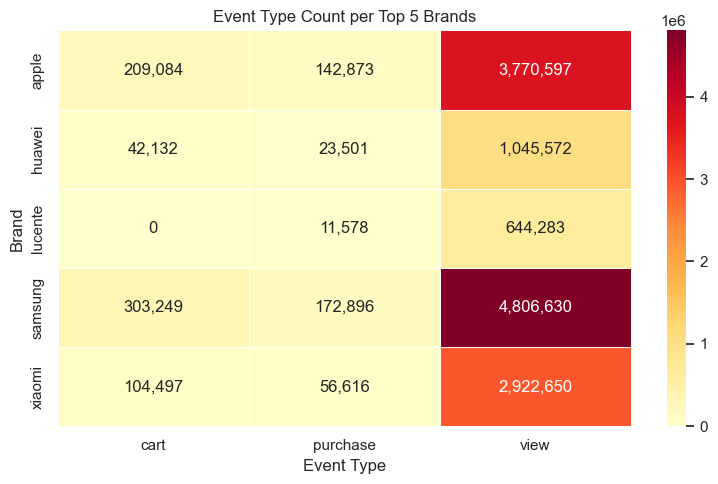

In [13]:
# Visualization of event type distribution across top 5 brands
# Heatmap — shows interaction intensity between brand and event type in a compact grid
# Best for identifying which brands drive the most purchases vs views

top_brands = df['brand'].value_counts().nlargest(5).index
df_top_brands = df[df['brand'].isin(top_brands)]

# Prepare pivot table: rows=brands, columns=event types, values=counts
brand_event = df_top_brands.groupby(['brand', 'event_type']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
sns.heatmap(brand_event, 
            annot=True,           # Show actual counts inside each cell
            fmt=',',              # Format numbers with commas
            cmap='YlOrRd',        # Yellow to Red colormap — higher values darker
            linewidths=0.5,       # Grid lines between cells
            linecolor='white')    # White grid lines for clean separation

plt.title('Event Type Count per Top 5 Brands')
plt.xlabel('Event Type')
plt.ylabel('Brand')
plt.tight_layout()
plt.show()

<Figure size 1400x800 with 0 Axes>

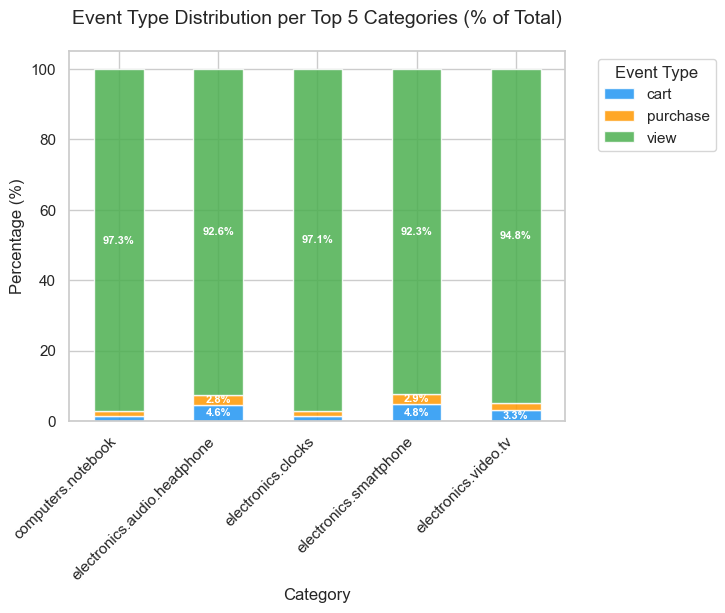

In [14]:
# Visualization of event type distribution across top 5 product categories
# 100% stacked bar — normalises counts to show conversion rate proportions per category
# Best for comparing funnel ratios across categories regardless of total volume differences

top_categories = df['category_code'].value_counts().nlargest(5).index
df_top_categories = df[df['category_code'].isin(top_categories)]

# Prepare and normalise data to percentages
category_event = df_top_categories.groupby(['category_code', 'event_type']).size().unstack(fill_value=0)
category_event_pct = category_event.div(category_event.sum(axis=1), axis=0) * 100  # Convert to percentage

colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue=view, Orange=cart, Green=purchase

# Create figure with constrained layout to prevent black space
plt.figure(figsize=(14, 8), constrained_layout=True)

category_event_pct.plot(kind='bar', stacked=True, 
                        color=colors, alpha=0.85, edgecolor='white')

# Add percentage labels inside each stack
for n, col in enumerate(category_event_pct.columns):
    for i, (idx, val) in enumerate(category_event_pct[col].items()):
        if val > 2:  # Only label if slice is large enough to display
            # Calculate cumulative position for label placement
            cumsum = category_event_pct.iloc[i, :n+1].sum()
            plt.text(i, cumsum - val/2,  
                     f'{val:.1f}%', ha='center', va='center', 
                     fontsize=8, fontweight='bold', color='white')

plt.title('Event Type Distribution per Top 5 Categories (% of Total)', fontsize=14, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Event Type', bbox_to_anchor=(1.05, 1))

# Remove tight_layout() since we're using constrained_layout
plt.show()